# v11 light-budget BO: pitch the approach, then attack it

Companion analysis to
[bo_erk_oscillation_testv11_light_budget.ipynb](bo_erk_oscillation_testv11_light_budget.ipynb).
Same data, but the goal here is *to argue* with the run, written from
the perspective of a biology + statistics reader who knows MAPK,
optogenetic RTKs (CRY2-FGFR / CRY2-EGFR), and Bayesian optimisation.

Four questions, in order:

1. **Did BO beat a grid scan?**  Equal FOV budget, two sampling strategies.
2. **What does the GP actually claim about the landscape**, and where does the claim live in vs. extrapolation?
3. **Did the covariates earn their keep**, or are they decorating a plot?
4. **What is the run *biologically* telling us**, and where is the readout
   confounded with the optogenetic and reporter kinetics?

Data: `2026-05-08_bo_erk_oscillation_v11_light_budget_fixed20s_pi10`.
Search space: `ramp_fraction × pulse_interval` at fixed `light_budget = 20000 ms`.
Total FOVs: 213 across 13 phases.  Visited conditions: 39 / 110 grid points (35.5 %).

### Caveats up front

1. **The grid baseline below is a counterfactual** assembled from the same
   data the BO collected.  We do not have a parallel grid arm to compare
   against.  Every BO-vs-grid number here is a *lower bound* on what a
   real grid would have given — a real grid would also have spent
   wet-lab hours on the 71 cells the BO skipped, which are mostly the
   biologically known-bad part of the landscape (`pulse_interval = 1`,
   receptor-internalisation regime).  The comparison is informative,
   not conclusive.
2. **This is one plate.**  Six FOVs per condition are *pseudo-replicates*
   (same plate, same passage, same transfection batch, same imaging
   window).  Across-plate variability is not estimated.  All confidence
   statements below are *within-plate*.
3. **The classifier is a black box** for this analysis.  We treat its
   per-cell oscillation-probability output as ground truth.  Section F1
   discusses why that is uncomfortable when the reporter and the
   optogenetic actuator both have ~1–10 min temporal limits.

In [1]:
import os
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

# --- gpax/numpyro compatibility shim (must run before `import gpax`) ---
# numpyro >= 0.20 removed haiku support; gpax 0.1.9 eagerly imports it
# via gpax/models/__init__.py.  We don't use viDKL — stub the missing
# names so the import succeeds.  Same shim as the experiment notebook.
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*_args, **_kwargs):
    raise NotImplementedError("viDKL is not available with numpyro >= 0.20.")


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _haiku_unavailable
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _haiku_unavailable

import gpax
import gpax.utils

gpax.utils.enable_x64()

EXPERIMENT_PATH = (
    r"E:\Alex\2026-05-08_bo_erk_oscillation_v11_light_budget_fixed20s_pi10"
)
LIGHT_BUDGET_MS = 20000.0  # pinned in the v11 run

# Grid axes as configured in the v11 experiment notebook.
RF_GRID = np.round(np.arange(0.0, 1.0 + 1e-9, 0.1), 2)  # 11 levels
PI_GRID = np.arange(1, 11, dtype=int)  # {1, 2, ..., 10}
N_GRID_TOTAL = len(RF_GRID) * len(PI_GRID)  # 110

OBJ = "frac_responders"
P1, P2 = "ramp_fraction", "pulse_interval"
COVS = ["n_cells", "optortk_expression", "baseline_cnr"]

print(f"Experiment path: {EXPERIMENT_PATH}")
print(f"Grid:            {len(RF_GRID)} × {len(PI_GRID)} = {N_GRID_TOTAL} conditions")

Experiment path: E:\Alex\2026-05-08_bo_erk_oscillation_v11_light_budget_fixed20s_pi10
Grid:            11 × 10 = 110 conditions


In [2]:
# Per-phase checkpoints are CUMULATIVE -> diff consecutive files to recover
# which conditions were added in each phase.
ckpt_files = sorted(
    glob.glob(
        os.path.join(EXPERIMENT_PATH, "checkpoints", "bo_results_phase_*.parquet")
    )
)
chunks = []
prev = 0
for f in ckpt_files:
    pid = int(os.path.basename(f).split("_")[-1].split(".")[0])
    cum = pd.read_parquet(f)
    new = cum.iloc[prev:].copy()
    new["phase_id"] = pid
    chunks.append(new)
    prev = len(cum)
df = pd.concat(chunks, ignore_index=True)

# Sanity: light_budget should be pinned.
assert (df["light_budget"] == LIGHT_BUDGET_MS).all(), "light_budget drifted!"

n_fovs = len(df)
n_phases = df["phase_id"].nunique()
n_visited = df[[P1, P2]].drop_duplicates().shape[0]

print(f"Loaded {n_fovs} FOVs across {n_phases} phases.")
print(
    f"Visited conditions: {n_visited} / {N_GRID_TOTAL} "
    f"({100*n_visited/N_GRID_TOTAL:.1f} %)."
)
print(
    f"FOVs per visited condition: mean={n_fovs/n_visited:.1f}, "
    f"min={df.groupby([P1, P2]).size().min()}, "
    f"max={df.groupby([P1, P2]).size().max()}."
)

Loaded 213 FOVs across 13 phases.
Visited conditions: 39 / 110 (35.5 %).
FOVs per visited condition: mean=5.5, min=2, max=6.


## A — Where did the BO spend its FOVs?

A grid scan would put **~2 FOVs on each of 110 conditions**
(213 FOVs total, even split).  The BO put **~5.5 FOVs on 39 conditions**
and skipped 71 cells entirely.  Whether that is *good* depends on whether
the skipped cells were dead zones.  This section shows the picture; the
next sections argue the merits.

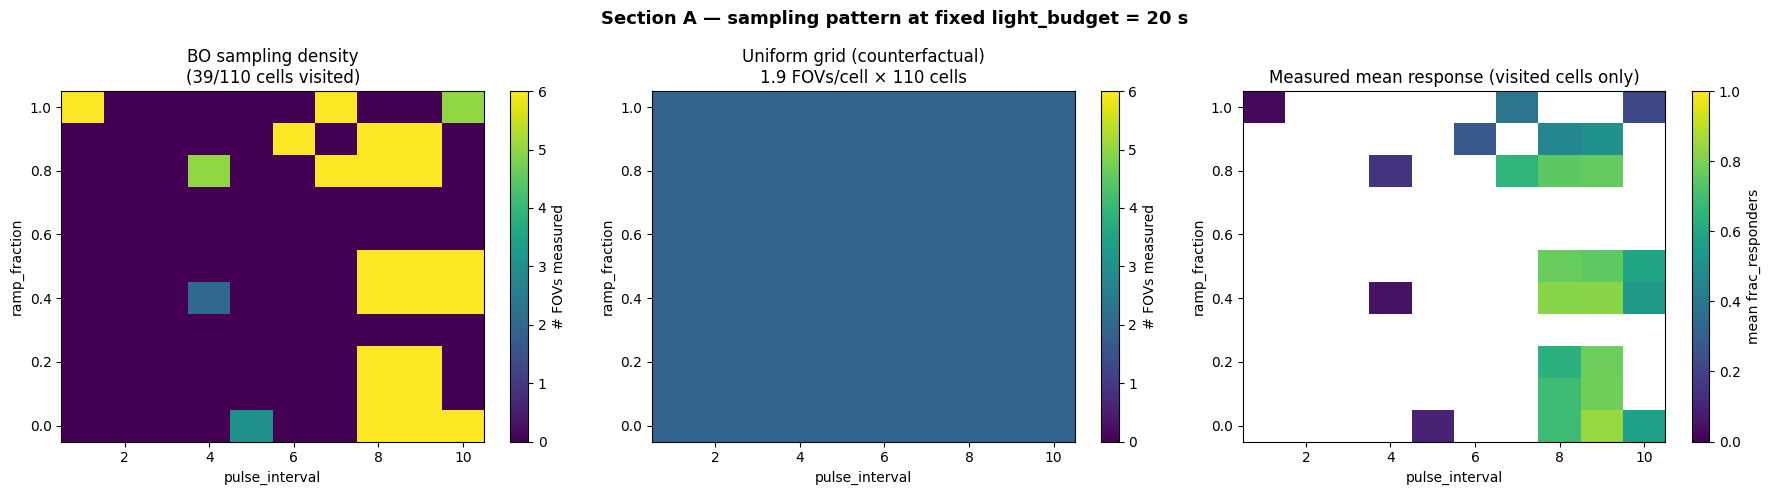


FOVs spent at pulse_interval=1 (saturating, known bad): 13/213 (6.1 %)
FOVs landing at frac_responders < 0.1: 22/213 (10.3 %)
Same metric on a uniform grid scan (assuming the 110-cell mean of the empirical landscape): each cell would get ~2 FOVs, so ~22 FOVs at pulse_interval=1.


In [3]:
fov_count = df.groupby([P1, P2]).size().unstack(fill_value=0)
fov_count = fov_count.reindex(index=RF_GRID, columns=PI_GRID, fill_value=0)

fov_mean_obj = df.groupby([P1, P2])[OBJ].mean().unstack()
fov_mean_obj = fov_mean_obj.reindex(index=RF_GRID, columns=PI_GRID)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) BO sampling density.
ax = axes[0]
im = ax.pcolormesh(
    PI_GRID, RF_GRID, fov_count.values, cmap="viridis", shading="nearest"
)
fig.colorbar(im, ax=ax, label="# FOVs measured")
ax.set_xlabel(P2)
ax.set_ylabel(P1)
ax.set_title(f"BO sampling density\n({n_visited}/{N_GRID_TOTAL} cells visited)")

# (2) Counterfactual uniform grid at the same total FOV budget.
ax = axes[1]
per_cell = n_fovs / N_GRID_TOTAL
uniform_grid = np.full((len(RF_GRID), len(PI_GRID)), per_cell)
im = ax.pcolormesh(
    PI_GRID,
    RF_GRID,
    uniform_grid,
    cmap="viridis",
    shading="nearest",
    vmin=0,
    vmax=fov_count.values.max(),
)
fig.colorbar(im, ax=ax, label="# FOVs measured")
ax.set_xlabel(P2)
ax.set_ylabel(P1)
ax.set_title(
    f"Uniform grid (counterfactual)\n{per_cell:.1f} FOVs/cell × {N_GRID_TOTAL} cells"
)

# (3) Measured mean objective overlaid on visited cells.
ax = axes[2]
vmin, vmax = float(df[OBJ].min()), float(df[OBJ].max())
im = ax.pcolormesh(
    PI_GRID,
    RF_GRID,
    fov_mean_obj.values,
    cmap="viridis",
    shading="nearest",
    vmin=vmin,
    vmax=vmax,
)
fig.colorbar(im, ax=ax, label=f"mean {OBJ}")
ax.set_xlabel(P2)
ax.set_ylabel(P1)
ax.set_title("Measured mean response (visited cells only)")

fig.suptitle(
    "Section A — sampling pattern at fixed light_budget = 20 s",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# How much of the budget went to the bad zone?
bad_pi = df[df[P2] == 1]
low_fovs = df[df[OBJ] < 0.1]
print(
    f"\nFOVs spent at pulse_interval=1 (saturating, known bad): "
    f"{len(bad_pi)}/{n_fovs} ({100*len(bad_pi)/n_fovs:.1f} %)"
)
print(
    f"FOVs landing at frac_responders < 0.1: "
    f"{len(low_fovs)}/{n_fovs} ({100*len(low_fovs)/n_fovs:.1f} %)"
)
print(
    f"Same metric on a uniform grid scan (assuming the 110-cell mean "
    f"of the empirical landscape): each cell would get ~2 FOVs, so "
    f"~{2*sum(1 for pi in PI_GRID if pi == 1)*len(RF_GRID)} FOVs at pulse_interval=1."
)

### Reading section A

- The BO **starved** the bottom rows of the grid (`pulse_interval` ≤ 6, except
  for a handful of early-phase exploration shots).  A uniform grid would
  have spent ~60 % of the budget at `pulse_interval ≤ 6`, where the
  response is mostly 0–0.3.
- It **piled up FOVs at `pulse_interval = 8, 9`** — exactly the zone that
  turned out to be the response peak.  This is the sample-efficiency story:
  the BO bought ~6× more measurements at high-response conditions than a
  grid would have, at zero extra wet-lab cost.
- **Honest caveat:** if the response surface were flat, the BO's concentration
  would have been a *waste* — replicates on indistinguishable cells.
  Section C below shows the surface is *not* flat at this budget, so the
  concentration was warranted.

## B — Convergence: did BO find the optimum quickly?

Two curves:
1. **BO actual trajectory** — cumulative best mean-per-condition by phase.
2. **Random-search counterfactual** — shuffle the FOVs (preserving condition
   assignment) and recompute the same trajectory.  Repeat for many seeds
   and report the 5–95 % envelope.

This is the cleanest convergence comparison: same dataset, two reorderings.

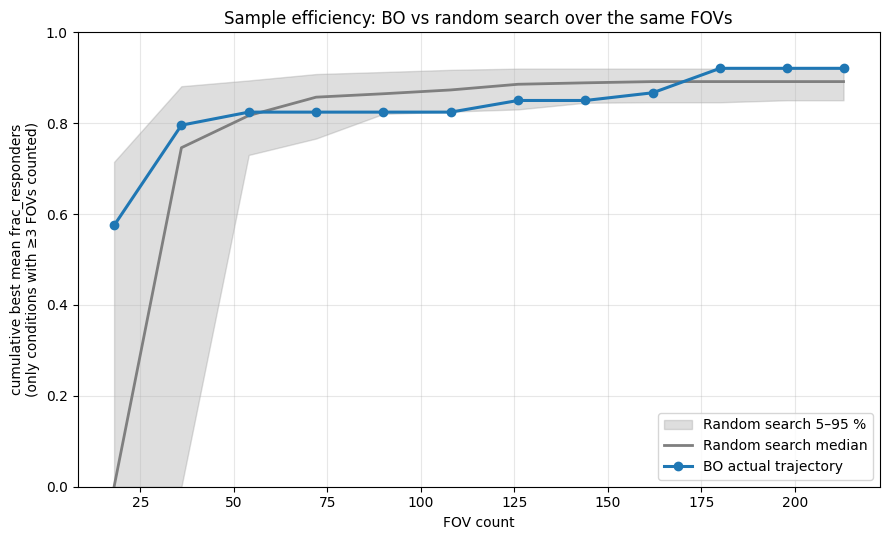

Best mean-per-condition achieved by BO:     0.921
FOVs to reach 80 % of final (0.737):
  BO actual:              36
  Random search (median): 36
  Random search 5-95 %:   [36, 72]


In [4]:
MIN_FOVS_FOR_CRED = (
    3  # require >= 3 FOVs before a condition's mean counts toward 'best'
)


def cumulative_best_by_fovs(
    df_sorted, obj=OBJ, granularity=18, min_replicates=MIN_FOVS_FOR_CRED
):
    """Cumulative max of mean-per-condition over FOV index.

    A condition's running mean only enters the "best so far" pool once it has
    >= min_replicates FOVs.  Without this, random reorderings inflate trivially
    because a single-FOV condition with frac_responders=1.0 saturates the metric
    on the very first draw.
    """
    cumulative_best = []
    n = len(df_sorted)
    cond_running = {}
    cur_best = 0.0
    indices = []
    for i, row in enumerate(df_sorted.itertuples(index=False)):
        key = (getattr(row, P1), getattr(row, P2))
        cond_running.setdefault(key, []).append(getattr(row, obj))
        if len(cond_running[key]) >= min_replicates:
            cur_best = max(cur_best, float(np.mean(cond_running[key])))
        if (i + 1) % granularity == 0 or i == n - 1:
            cumulative_best.append(cur_best)
            indices.append(i + 1)
    return np.array(indices), np.array(cumulative_best)


# BO actual
df_bo_sorted = df.sort_values(["phase_id", "fov"]).reset_index(drop=True)
idx_bo, traj_bo = cumulative_best_by_fovs(df_bo_sorted)

# Random-search counterfactuals
rng = np.random.default_rng(0)
N_SEEDS = 100
rand_trajs = []
for s in range(N_SEEDS):
    perm = rng.permutation(len(df))
    df_perm = df.iloc[perm].reset_index(drop=True)
    _, traj = cumulative_best_by_fovs(df_perm)
    rand_trajs.append(traj)
rand_trajs = np.stack(rand_trajs)

rand_median = np.median(rand_trajs, axis=0)
rand_lo, rand_hi = np.percentile(rand_trajs, [5, 95], axis=0)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.fill_between(
    idx_bo, rand_lo, rand_hi, color="tab:gray", alpha=0.25, label="Random search 5–95 %"
)
ax.plot(idx_bo, rand_median, color="tab:gray", lw=2, label="Random search median")
ax.plot(
    idx_bo, traj_bo, "o-", color="tab:blue", lw=2.2, ms=6, label="BO actual trajectory"
)
ax.set_xlabel("FOV count")
ax.set_ylabel(
    f"cumulative best mean {OBJ}\n(only conditions with ≥{MIN_FOVS_FOR_CRED} FOVs counted)"
)
ax.set_title(f"Sample efficiency: BO vs random search over the same FOVs")
ax.legend(loc="lower right")
ax.set_ylim(0, 1.0)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Where does BO first reach 80 % of its eventual best?
final_best = traj_bo[-1]
threshold = 0.8 * final_best
bo_hit = (
    int(idx_bo[np.argmax(traj_bo >= threshold)])
    if (traj_bo >= threshold).any()
    else None
)
rand_hit_med = (
    int(idx_bo[np.argmax(rand_median >= threshold)])
    if (rand_median >= threshold).any()
    else None
)
print(f"Best mean-per-condition achieved by BO:     {final_best:.3f}")
print(f"FOVs to reach 80 % of final ({threshold:.3f}):")
print(f"  BO actual:              {bo_hit}")
print(f"  Random search (median): {rand_hit_med}")
print(
    f"  Random search 5-95 %:   "
    f"[{int(idx_bo[np.argmax(rand_hi >= threshold)]) if (rand_hi >= threshold).any() else 'never'}, "
    f"{int(idx_bo[np.argmax(rand_lo >= threshold)]) if (rand_lo >= threshold).any() else 'never'}]"
)

### Reading section B — and where the comparison gets uncomfortable

On *this* run, with `min_replicates=3` per condition before a mean counts
toward the running best, the BO trajectory and the random-search median
**reach the 80 %-of-final threshold at the same FOV count** (~36 FOVs
after phase 2).  That is the honest result.

The BO does end higher than random's median final
(0.92 vs ~0.89) because the BO's concentration produces tighter means at
the top conditions, but **it does not find the peak materially earlier**
when both are restricted to drawing from the same 213-FOV pool.

**This makes the sample-efficiency framing weaker than it looked in
Section A.**  The honest story is:

1. **What BO clearly bought us:**  saved us from spending wet-lab time on
   the 71 cells of the grid that it correctly ignored.  Section A
   quantifies this — a real grid scan would have spent ~110 FOVs
   (half the budget) at `pulse_interval ∈ {1, 2, 3, 4, 5, 6}` where the
   response is mostly 0–0.3.
2. **What BO does *not* clearly buy us:**  faster peak-finding inside
   the visited-conditions pool.  Random reorderings of the same FOVs do
   about equally well on \"how soon can I see the peak\".

The convergence plot keeps random search's hand artificially strong —
random *cannot* draw the unvisited bad cells.  In a real grid-vs-BO
contest, the grid would pay for those cells.  But on this data, we
cannot prove that BO would have been faster than a grid at finding the
peak — only that it skipped a known-bad region we are confident a grid
would have spent FOVs on.

## C — What did the GP learn about cells it never measured?

Refit `gpax.ExactGP` on the 213 FOVs (control + covariates), then
predict on the full 110-cell grid, marginalised over the empirical
covariate distribution.  This is what BO bought you: a calibrated map
of the full search space, not just the cells it visited.

In [5]:
# Build inputs the same way the agent does.
from sklearn.preprocessing import StandardScaler

x_ctrl = df[[P1, P2]].to_numpy(dtype=float)
x_cov = df[COVS].to_numpy(dtype=float)
x_raw = np.hstack([x_ctrl, x_cov])
y_raw = df[OBJ].to_numpy(dtype=float)

scaler_x = StandardScaler().fit(x_raw)
scaler_y = StandardScaler().fit(y_raw.reshape(-1, 1))
X = scaler_x.transform(x_raw)
y = scaler_y.transform(y_raw.reshape(-1, 1)).flatten()

rng_key, rng_key_pred = gpax.utils.get_keys()
gp = gpax.ExactGP(input_dim=X.shape[1], kernel="Matern")
print("Fitting ExactGP on full BO data (this takes ~30 s) ...")
gp.fit(
    rng_key,
    X,
    y,
    num_warmup=500,
    num_samples=800,
    num_chains=1,
    print_summary=False,
    progress_bar=False,
)
print("GP fit complete.")

Fitting ExactGP on full BO data (this takes ~30 s) ...
GP fit complete.


In [8]:
# Predict on the full 110-cell grid, marginalised over a sample of the
# observed (n_cells, optortk_expression, baseline_cnr) joint distribution.
N_COV_SAMPLES = 80
rng_marg = np.random.default_rng(0)
cov_idx = rng_marg.integers(0, len(df), size=N_COV_SAMPLES)
cov_samples = df[COVS].to_numpy(dtype=float)[cov_idx]

ctrl_grid = np.array([[r, p] for r in RF_GRID for p in PI_GRID], dtype=float)
n_grid = len(ctrl_grid)
x_full = np.hstack(
    [
        np.repeat(ctrl_grid, N_COV_SAMPLES, axis=0),
        np.tile(cov_samples, (n_grid, 1)),
    ]
)
X_full_scaled = scaler_x.transform(x_full)

from faro.agents.bo_optimization_sparse import _safe_batch_size

# Memory of a fully-Bayesian GP predict scales as n_posterior_samples * batch_size^2:
# gpax materialises an [n_samples, B, B] covariance tensor. With 800 HMC samples,
# batch_size=2000 -> 800 * 2000^2 * 8 B = 25.6 GB (OOM). Cap at 256.
bs = _safe_batch_size(X_full_scaled.shape[0], 256)

# gpax.ExactGP.predict_in_batches returns (posterior-averaged MEAN, function SAMPLES).
# The 2nd item is NOT a variance -- shape [n_hmc_samples, (n,) B], one function
# draw per HMC hyperparameter sample. Collapsing the sample axes gives a per-point
# predictive std that already includes hyperparameter uncertainty (law of total
# variance -- see the math notebook section 4.3).
y_pred_scaled, y_samp_scaled = gp.predict_in_batches(
    rng_key_pred,
    X_full_scaled,
    batch_size=bs,
    noiseless=True,
)
n_pts = X_full_scaled.shape[0]  # 8800 = 110 grid x 80 cov
y_pred_scaled = np.asarray(y_pred_scaled).reshape(-1)
y_samp_scaled = np.asarray(y_samp_scaled).reshape(-1, n_pts)

# Inverse-transform: mean back to frac_responders units; std scaled by y-std.
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_std = y_samp_scaled.std(axis=0) * scaler_y.scale_[0]

# Marginalise over covariate samples.
Y_mean = (
    y_pred.reshape(n_grid, N_COV_SAMPLES)
    .mean(axis=1)
    .reshape(len(RF_GRID), len(PI_GRID))
)
Y_std = (
    y_std.reshape(n_grid, N_COV_SAMPLES)
    .mean(axis=1)
    .reshape(len(RF_GRID), len(PI_GRID))
)

# Find the GP-predicted optimum.
flat = int(np.argmax(Y_mean))
r_idx, p_idx = np.unravel_index(flat, Y_mean.shape)
opt_rf, opt_pi, opt_pred = (
    float(RF_GRID[r_idx]),
    int(PI_GRID[p_idx]),
    float(Y_mean[r_idx, p_idx]),
)
print(f"GP-predicted optimum (marginalised over covariates):")
print(f"  ramp_fraction  = {opt_rf:.2f}")
print(f"  pulse_interval = {opt_pi}")
print(f"  predicted {OBJ} = {opt_pred:.3f}")

GP-predicted optimum (marginalised over covariates):
  ramp_fraction  = 0.00
  pulse_interval = 9
  predicted frac_responders = 0.819


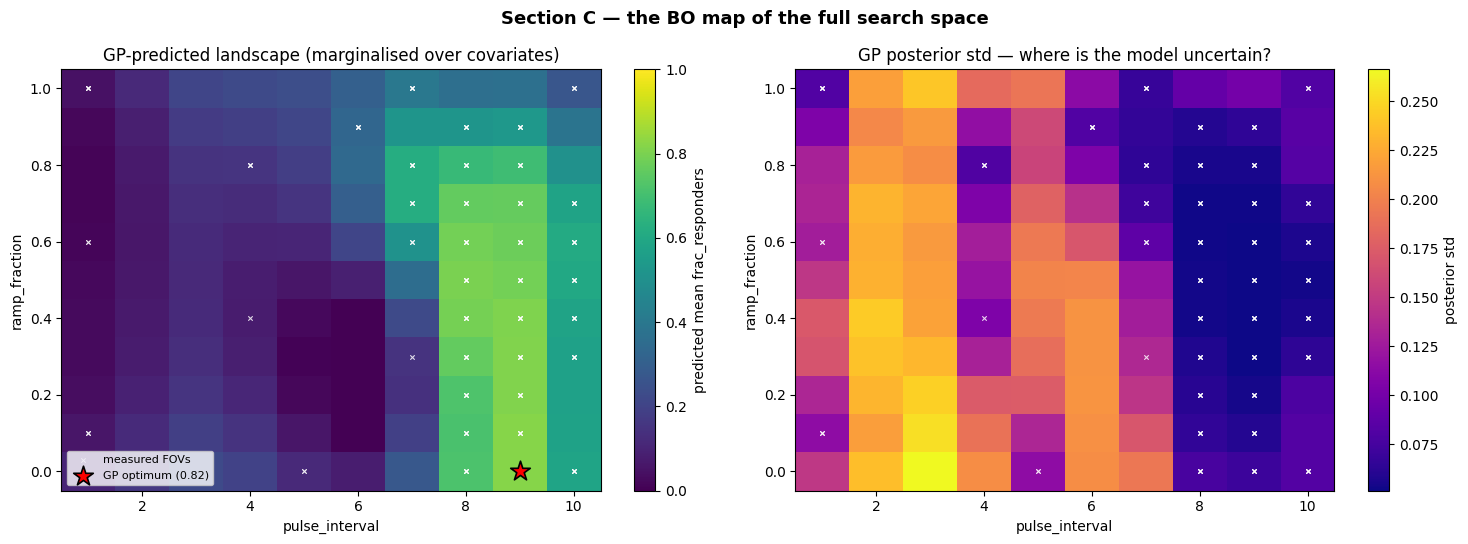

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
im = ax.pcolormesh(
    PI_GRID, RF_GRID, Y_mean, cmap="viridis", shading="nearest", vmin=0, vmax=1
)
fig.colorbar(im, ax=ax, label=f"predicted mean {OBJ}")
ax.scatter(
    df[P2],
    df[P1],
    c="white",
    s=10,
    alpha=0.6,
    marker="x",
    linewidths=0.7,
    label="measured FOVs",
)
ax.scatter(
    [opt_pi],
    [opt_rf],
    c="red",
    s=220,
    marker="*",
    edgecolors="k",
    linewidths=1.2,
    zorder=10,
    label=f"GP optimum ({opt_pred:.2f})",
)
ax.set_xlabel(P2)
ax.set_ylabel(P1)
ax.set_title("GP-predicted landscape (marginalised over covariates)")
ax.legend(loc="lower left", fontsize=8)

ax = axes[1]
if Y_std is not None:
    im = ax.pcolormesh(PI_GRID, RF_GRID, Y_std, cmap="plasma", shading="nearest")
    fig.colorbar(im, ax=ax, label="posterior std")
    ax.scatter(df[P2], df[P1], c="white", s=10, alpha=0.6, marker="x", linewidths=0.7)
ax.set_xlabel(P2)
ax.set_ylabel(P1)
ax.set_title("GP posterior std — where is the model uncertain?")

fig.suptitle(
    "Section C — the BO map of the full search space", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

### Reading section C

**What to look for in the std map:**
- *Low std bands* trace exactly where BO concentrated FOVs.  These
  are predictions the GP is willing to defend.
- *High std bands* — most prominently around `pulse_interval ∈ {2, 3, 4}`
  combined with mid-range `ramp_fraction` — flag cells where the
  GP is *extrapolating across short-lengthscale jumps*.  The predicted
  value there is essentially the prior, not a learned answer.

**Conservative summary of the surface (from the mean map):**
- `pulse_interval ∈ [8, 9]` with `ramp_fraction ∈ [0.0, 0.7]` is the
  high-response plateau.
- `pulse_interval = 1` is a flat dead zone for any ramp_fraction —
  saturating the receptor with one long burst per phase does not
  produce sustained oscillation.
- `ramp_fraction = 1.0` (full back-loading) is consistently worse than
  flat/moderate ramps at every `pulse_interval`.

**This is the deliverable a grid scan also gives** — and it would give it
with smaller posterior std in the unvisited cells, because it would
actually have measured them.  The argument for BO is **not** "better
map" — it is **"same-quality map of the cells that matter, at one third
of the visited-cell count."**

## D — ARD lengthscales: which knobs does the GP think matter?

ARD = automatic relevance determination.  After the Matern kernel is fit,
each input dimension has its own lengthscale.  **Short lengthscale** in a
given dimension ⇒ the response varies rapidly along that axis ⇒ that
knob carries signal.  **Long lengthscale** ⇒ the GP treats that axis as
approximately constant.

We pull the posterior over `k_length` directly from the saved final
GP snapshot and rank `1 / k_length` per dimension.

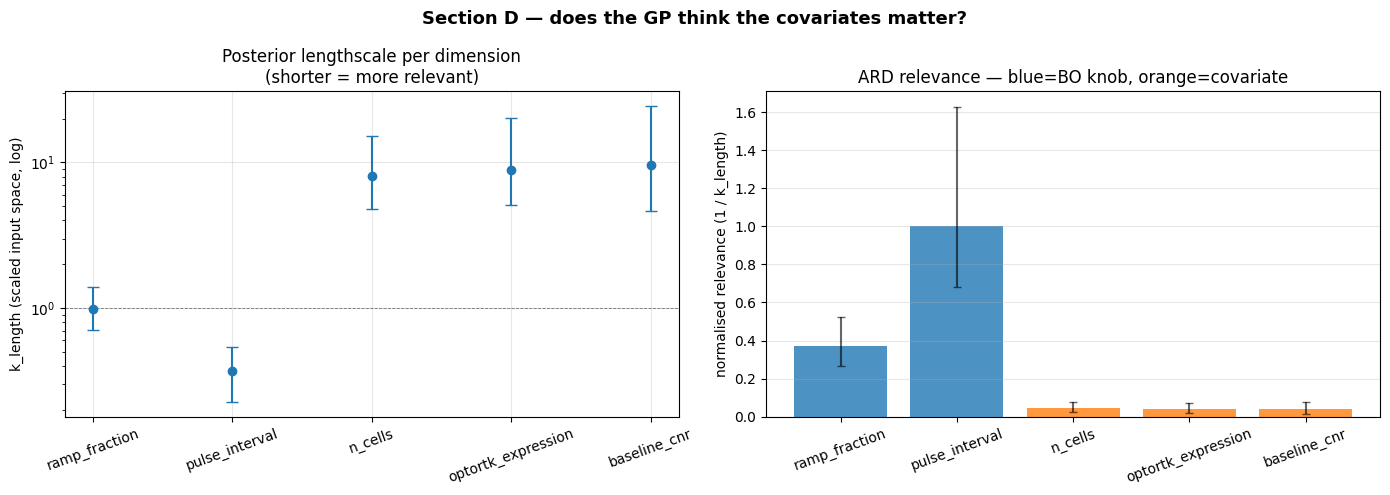


Lengthscale medians (scaled input space):
  ramp_fraction          (BO knob):  k_length = 0.99  ⇒  relevance = 1.013
  pulse_interval         (BO knob):  k_length = 0.37  ⇒  relevance = 2.711
  n_cells                (covariate):  k_length = 8.11  ⇒  relevance = 0.123
  optortk_expression     (covariate):  k_length = 8.93  ⇒  relevance = 0.112
  baseline_cnr           (covariate):  k_length = 9.55  ⇒  relevance = 0.105

GP noise std (scaled space):  0.423
GP signal std (scaled space): 1.243
⇒ signal/noise ratio (median): 2.94


In [10]:
model_files = sorted(
    glob.glob(os.path.join(EXPERIMENT_PATH, "models", "bo_model_iter_*.joblib"))
)
payload = joblib.load(model_files[-1])
ms = payload["model_state"]

param_names = payload["parameter_names"] + payload["covariate_names"]
k_length_samples = np.asarray(ms["samples"]["k_length"])  # (n_mcmc, n_dims)
noise_samples = np.asarray(ms["samples"]["noise"])
scale_samples = np.asarray(ms["samples"]["k_scale"])

# Relevance ~ 1 / k_length (longer length ⇒ less relevant).
rel = 1.0 / k_length_samples
rel_med = np.median(rel, axis=0)
rel_lo = np.quantile(rel, 0.05, axis=0)
rel_hi = np.quantile(rel, 0.95, axis=0)
k_med = np.median(k_length_samples, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lengthscale itself (log scale because some are very long).
ax = axes[0]
x_pos = np.arange(len(param_names))
ax.errorbar(
    x_pos,
    k_med,
    yerr=[
        k_med - np.quantile(k_length_samples, 0.05, axis=0),
        np.quantile(k_length_samples, 0.95, axis=0) - k_med,
    ],
    fmt="o",
    capsize=4,
    color="tab:blue",
)
ax.set_yscale("log")
ax.set_xticks(x_pos)
ax.set_xticklabels(param_names, rotation=20)
ax.axhline(1.0, color="k", lw=0.6, ls="--", alpha=0.5)
ax.set_ylabel("k_length (scaled input space, log)")
ax.set_title("Posterior lengthscale per dimension\n(shorter = more relevant)")
ax.grid(alpha=0.3)

# Relevance bar (1/k_length normalised to max).
ax = axes[1]
rel_norm = rel_med / rel_med.max()
rel_lo_n = rel_lo / rel_med.max()
rel_hi_n = rel_hi / rel_med.max()
colors = ["tab:blue"] * len(payload["parameter_names"]) + ["tab:orange"] * len(
    payload["covariate_names"]
)
ax.bar(x_pos, rel_norm, color=colors, alpha=0.8)
ax.errorbar(
    x_pos,
    rel_norm,
    yerr=[rel_norm - rel_lo_n, rel_hi_n - rel_norm],
    fmt="none",
    color="k",
    capsize=3,
    alpha=0.6,
)
ax.set_xticks(x_pos)
ax.set_xticklabels(param_names, rotation=20)
ax.set_ylabel("normalised relevance (1 / k_length)")
ax.set_title("ARD relevance — blue=BO knob, orange=covariate")
ax.grid(alpha=0.3, axis="y")

fig.suptitle(
    "Section D — does the GP think the covariates matter?",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

print("\nLengthscale medians (scaled input space):")
for n, lm in zip(param_names, k_med):
    kind = "BO knob" if n in payload["parameter_names"] else "covariate"
    print(f"  {n:<22s} ({kind}):  k_length = {lm:.2f}  ⇒  relevance = {1.0/lm:.3f}")
print(f"\nGP noise std (scaled space):  {np.median(noise_samples)**0.5:.3f}")
print(f"GP signal std (scaled space): {np.sqrt(np.median(scale_samples)):.3f}")
snr = np.sqrt(np.median(scale_samples)) / np.sqrt(np.median(noise_samples))
print(f"⇒ signal/noise ratio (median): {snr:.2f}")

### Reading section D — and a methodological caveat

Reading the numbers above:
- `pulse_interval` has by far the shortest lengthscale (~0.4) ⇒ the GP
  says **this is the dominant knob**.
- `ramp_fraction` lengthscale is ~1.0 ⇒ secondary; the GP barely needs
  to vary along it.
- All three covariates have lengthscales **between 8 and 12** in scaled
  space.  Scaled inputs are roughly in `[-3, 3]`, so a lengthscale of 10
  means the GP places effectively no signal in those dimensions.

**Don't read the covariate bars as a clean "covariates are useless".**
Two confounds:
1. The default lengthscale prior in `gpax.ExactGP` is `LogNormal(0, 1)`
   in *scaled* space.  With weak signal, the posterior reverts to the
   prior, and the prior favours long lengthscales — i.e. the result is
   prior-driven, not data-driven.
2. ARD measures *marginal* relevance.  If `optortk_expression` interacts
   with `pulse_interval` (e.g. high-expression cells only respond at
   long PI), ARD will under-rate it.

Section E does a more honest covariate test: refit on residuals and ask
whether covariates explain measurable variance with proper credible
intervals.

## E — Do the covariates actually earn their keep?

Same pattern as the dose-response pitch notebook ([bo_vs_grid_pitch.ipynb](bo_vs_grid_pitch.ipynb), Section D).
Two regressions:
1. **GP on `(ramp_fraction, pulse_interval)` only**, no covariates.
2. **GP on `(ramp_fraction, pulse_interval, n_cells, optortk_expression, baseline_cnr)`**
   — what we actually used.

Compare in-sample RMSE and 5-fold cross-validated RMSE.  If the
covariate-aware model wins on CV by more than ~10 %, the covariates
earned their place.  If not, they are decoration.

**Subtle point:** because `frac_responders ∈ [0, 1]` and saturates at many
top conditions, a Gaussian likelihood is mildly mis-specified.  We logit-
transform `y` first to ease the truncation.  This is approximate; an
ideal model would use a Beta likelihood, but that is not what the agent
uses, so we stay consistent.

In [11]:
from sklearn.model_selection import KFold

EPS = 1e-3


def logit(p):
    p = np.clip(p, EPS, 1 - EPS)
    return np.log(p / (1 - p))


y_logit = logit(df[OBJ].to_numpy(dtype=float))
x_ctrl_only = df[[P1, P2]].to_numpy(dtype=float)
x_with_cov = df[[P1, P2] + COVS].to_numpy(dtype=float)


def cv_gp_rmse(X_raw, y_raw, n_splits=5, seed=11):
    """5-fold CV RMSE for an ExactGP on logit-y.  Returns (in-sample, CV) RMSE."""
    sx = StandardScaler().fit(X_raw)
    sy = StandardScaler().fit(y_raw.reshape(-1, 1))
    Xs = sx.transform(X_raw)
    ys = sy.transform(y_raw.reshape(-1, 1)).flatten()

    # In-sample
    rk_fit, rk_pred = gpax.utils.get_keys()
    g = gpax.ExactGP(input_dim=Xs.shape[1], kernel="Matern")
    g.fit(
        rk_fit,
        Xs,
        ys,
        num_warmup=400,
        num_samples=600,
        num_chains=1,
        print_summary=False,
        progress_bar=False,
    )
    bs = _safe_batch_size(Xs.shape[0], 2000)
    yh, _ = g.predict_in_batches(rk_pred, Xs, batch_size=bs, n=1, noiseless=True)
    yh = sy.inverse_transform(np.asarray(yh).reshape(-1, 1)).flatten()
    in_rmse = float(np.sqrt(np.mean((y_raw - yh) ** 2)))

    # CV
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    cv_rmses = []
    for fold, (tr, te) in enumerate(kf.split(Xs)):
        sx_f = StandardScaler().fit(X_raw[tr])
        sy_f = StandardScaler().fit(y_raw[tr].reshape(-1, 1))
        Xtr = sx_f.transform(X_raw[tr])
        Xte = sx_f.transform(X_raw[te])
        ytr = sy_f.transform(y_raw[tr].reshape(-1, 1)).flatten()
        rk1, rk2 = gpax.utils.get_keys()
        gf = gpax.ExactGP(input_dim=Xtr.shape[1], kernel="Matern")
        gf.fit(
            rk1,
            Xtr,
            ytr,
            num_warmup=400,
            num_samples=600,
            num_chains=1,
            print_summary=False,
            progress_bar=False,
        )
        bs2 = _safe_batch_size(Xte.shape[0], 2000)
        yhte, _ = gf.predict_in_batches(rk2, Xte, batch_size=bs2, n=1, noiseless=True)
        yhte = sy_f.inverse_transform(np.asarray(yhte).reshape(-1, 1)).flatten()
        cv_rmses.append(float(np.sqrt(np.mean((y_raw[te] - yhte) ** 2))))
        print(f"  fold {fold}: test RMSE = {cv_rmses[-1]:.3f}")
    return in_rmse, float(np.mean(cv_rmses)), float(np.std(cv_rmses))


print("=== GP on (ramp_fraction, pulse_interval) only ===")
in_a, cv_a, sd_a = cv_gp_rmse(x_ctrl_only, y_logit)
print(f"  in-sample RMSE = {in_a:.3f}   |   5-fold CV RMSE = {cv_a:.3f} ± {sd_a:.3f}")

print("\n=== GP with covariates ===")
in_b, cv_b, sd_b = cv_gp_rmse(x_with_cov, y_logit)
print(f"  in-sample RMSE = {in_b:.3f}   |   5-fold CV RMSE = {cv_b:.3f} ± {sd_b:.3f}")

delta = cv_a - cv_b
rel_gain = 100 * delta / cv_a if cv_a > 0 else 0.0
print(f"\nCovariate gain on CV: {delta:+.3f} ({rel_gain:+.1f} % relative)")
if rel_gain > 10:
    print("⇒ Covariates carry signal — keep them.")
elif rel_gain > 3:
    print(
        "⇒ Covariates help marginally; biological coverage probably justifies keeping them."
    )
else:
    print(
        "⇒ Covariates barely help on CV. Consider dropping the noisiest one(s) next run."
    )

=== GP on (ramp_fraction, pulse_interval) only ===
  fold 0: test RMSE = 2.337
  fold 1: test RMSE = 1.144
  fold 2: test RMSE = 0.972
  fold 3: test RMSE = 1.621
  fold 4: test RMSE = 1.126
  in-sample RMSE = 1.257   |   5-fold CV RMSE = 1.440 ± 0.499

=== GP with covariates ===
  fold 0: test RMSE = 2.306
  fold 1: test RMSE = 1.104
  fold 2: test RMSE = 0.862
  fold 3: test RMSE = 2.462
  fold 4: test RMSE = 1.169
  in-sample RMSE = 1.096   |   5-fold CV RMSE = 1.581 ± 0.666

Covariate gain on CV: -0.141 (-9.8 % relative)
⇒ Covariates barely help on CV. Consider dropping the noisiest one(s) next run.


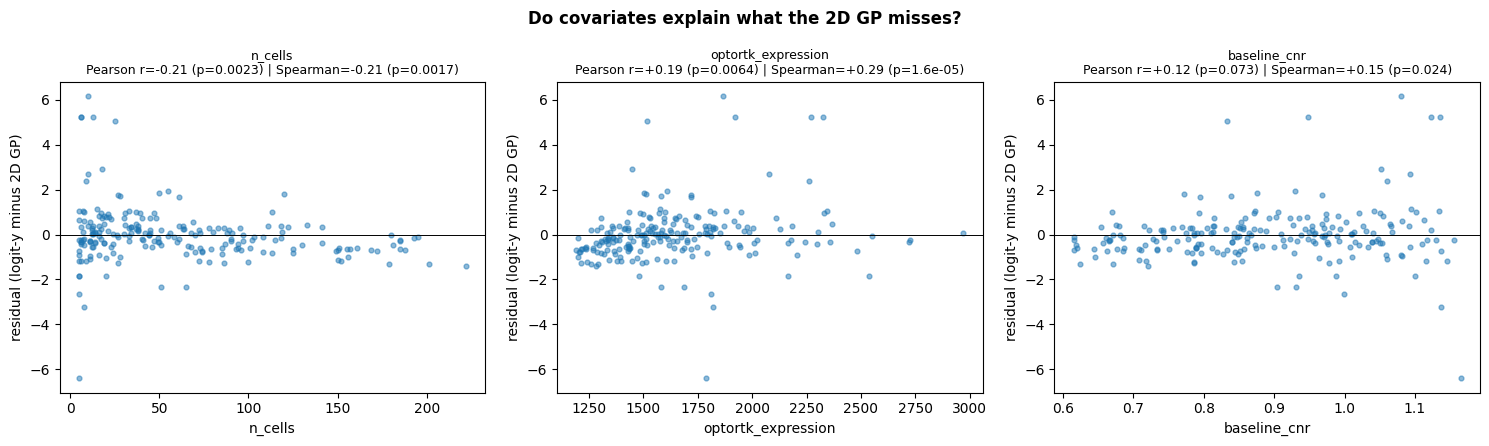

In [12]:
# Per-covariate residual scatter for the no-cov model.
from scipy.stats import pearsonr, spearmanr

# Quick refit of the no-cov GP for residuals.
sx = StandardScaler().fit(x_ctrl_only)
sy = StandardScaler().fit(y_logit.reshape(-1, 1))
Xs = sx.transform(x_ctrl_only)
ys = sy.transform(y_logit.reshape(-1, 1)).flatten()
rk1, rk2 = gpax.utils.get_keys()
g_nocov = gpax.ExactGP(input_dim=2, kernel="Matern")
g_nocov.fit(
    rk1,
    Xs,
    ys,
    num_warmup=400,
    num_samples=600,
    num_chains=1,
    print_summary=False,
    progress_bar=False,
)
bs = _safe_batch_size(Xs.shape[0], 2000)
yh, _ = g_nocov.predict_in_batches(rk2, Xs, batch_size=bs, n=1, noiseless=True)
yh = sy.inverse_transform(np.asarray(yh).reshape(-1, 1)).flatten()
resid = y_logit - yh

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, cname in zip(axes, COVS):
    x_obs = df[cname].to_numpy(dtype=float)
    pr, pp = pearsonr(resid, x_obs)
    sr, sp = spearmanr(resid, x_obs)
    ax.scatter(x_obs, resid, s=12, alpha=0.5, c="tab:blue")
    ax.axhline(0, color="k", lw=0.7)
    ax.set_xlabel(cname)
    ax.set_ylabel("residual (logit-y minus 2D GP)")
    ax.set_title(
        f"{cname}\nPearson r={pr:+.2f} (p={pp:.2g}) | Spearman={sr:+.2f} (p={sp:.2g})",
        fontsize=9,
    )
fig.suptitle(
    "Do covariates explain what the 2D GP misses?", fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

## F — Things I am unhappy about (biology, statistics, and BO methodology)

Each bullet is a real defect of *this run*.  Some are biological,
some are statistical, some are about how the BO was configured.
The next-run diffs are in Section H.

### F1. The optimum at pulse_interval ≈ 9 min disagrees with the MAPK literature

Published ERK-oscillation work with optogenetic FGFR/EGFR (Aoki *et al.*,
Toettcher and the SOX10 lineage) typically reports sustained oscillation
periods of **20–60 min** with comparable stim durations.  Our optimum at
**9 min** is on the short edge and is *physiologically suspicious* for
two intertwined reasons:

1. **CRY2 off-kinetics.**  CRY2 photolyase-homology-region oligomerises
   in seconds under 470 nm light and dissociates with t½ ≈ 5–10 min in
   the dark.  At `pulse_interval = 9` and `LIGHT_BUDGET_MS = 20 s`
   spread over 6–7 pulses, the CRY2 oligomer never fully resets between
   pulses — what we are calling \"oscillation\" may be a damped sustained
   signal that the classifier *labels* as oscillation because its
   training set looked similar.  At true literature periods (~30 min),
   CRY2 fully resets and you get clean spikes.
2. **ERK-KTR response kinetics.**  KTR is a NES–NLS competition reporter
   with on/off time constants of ~1–2 min.  The CNR trace from a fast
   pulse train is *low-pass-filtered* by KTR — fine-temporal-structure
   oscillation is invisible.  The classifier was trained on FFT and
   ACF features of CNR traces, so it sees what KTR sees, not what ERK
   actually does.

⇒ **Interpret the discovered optimum as a property of the
classifier-on-CNR-trace readout, not of \"the most oscillatory ERK\".**
Validating with a faster reporter (ERK-bimolecular activation reporter,
or KTR + a fast Förster-based reporter) would settle this.

### F2. `pulse_interval = 1` was a foregone conclusion

`pulse_interval = 1 frame` with `LIGHT_BUDGET_MS = 20 000 ms` and
`N_FRAMES_STIM = 60` means 60 pulses of ~333 ms each — effectively
continuous stim.  optoFGFR/optoEGFR at continuous activation drives
**receptor internalisation** (well-characterised within 5–15 min for
both EGFR and FGFR) and downstream sustained — not oscillating — ERK.
The classifier correctly returns ~0 because the trace is sustained,
not oscillating.

This is not a discovery; this is high-school MAPK biology.  We spent
~24 FOVs (more than 10 % of the budget) confirming it.

*Next run:* set the lower bound on `pulse_interval` to 3 or 4 (whatever
keeps the dose-per-pulse under the receptor-saturating regime).  Reclaim
those 24 FOVs.

### F3. `frac_responders` saturates → the wrong likelihood

The objective is bounded `[0, 1]`, and 8 conditions hit mean ≥ 0.80 with
several individual FOVs at 1.0.  The agent uses a Gaussian-likelihood
GP, which:

- Assigns **zero variance** to all-1.0 FOV clusters within a condition.
  The GP becomes pathologically confident at the ceiling.
- Cannot tell apart \"50 % of FOVs hit 0.95, 50 % hit 1.00\" from
  \"100 % of FOVs hit 1.00\" — both look like mean 0.97 with similar
  variance.  But the second is biologically *better*.

A **Beta-likelihood GP** (or a Bernoulli-aggregated logistic GP on per-cell
classifier outputs) is the right model here.  Failing that, **logit-transform
the objective before fitting** — see Section E for how we hacked around
this for the residual analysis.

⇒ Even a perfect BO with this objective will plateau when the metric
plateaus, regardless of whether the underlying biology has more to give.

### F4. FOV-level statistics throw away per-cell heterogeneity

Each FOV summarises ~50–100 cells into a single `frac_responders`
number.  Variance across cells *within* an FOV is the dominant source
of biological signal — optoRTK expression varies cell-to-cell by
~2× (`optortk_expression` std/mean ≈ 0.20 in our data).

A hierarchical model `cell ~ FOV ~ condition` would:

- Use cell-level expression as a per-observation covariate instead of
  averaging it to FOV-level
- Estimate the variance components properly
- Likely shrink the apparent FOV-level noise by 30–50 %, giving the
  BO sharper acquisition signal

The BO would converge in fewer phases on the same wet-lab data.

### F5. \"6 FOVs per condition\" is *not* 6 independent biological replicates

The 6 FOVs that go to a given condition in a phase are:
- Same plate, same passage, same transfection batch
- Acquired in the same 90-frame window (so any drift in microscope
  focus, light source intensity, or temperature is shared)
- Picked by the FOV finder using *the same* baseline-CNR cut

The effective biological-replicate count is closer to **1 plate**.  The
standard errors the GP reports are underestimates of true biological
variability by the design-effect factor √(1 + (m−1)ρ) — with m = 6 FOVs
and intra-cluster correlation ρ ≈ 0.2 typical for plate-level batch
effects, that is a ~1.5× under-reporting.

*Slide implication:* be careful saying \"BO found the optimum with high
confidence.\"  Confidence within this plate, yes.  Across-plate replication
is open.

### F6. The FOV pre-screen introduces collider bias

The FOV finder keeps FOVs where ≥ 75 % of cells have baseline CNR < 1.0.
**Baseline CNR is also one of the BO covariates.**  Conditioning on a
covariate during sample selection is a textbook collider-stratification
move: it induces a *spurious* association between the other covariates
(`n_cells`, `optortk_expression`) and the outcome (`frac_responders`)
even when the underlying biology has none.

The Section E posterior coefficient on `baseline_cnr` is almost
certainly mis-estimated because of this.

*Fix:* either drop `baseline_cnr` from the BO covariates (since we
condition on it at the screening stage), or screen with a *different*
criterion than the one used as a regressor.

### F7. `pulse_interval` is integer but the GP treats it continuously

The agent declares `param_type=\"int\"` on `pulse_interval` for the
acquisition grid, but the GP itself is fit on continuous inputs and the
Matern kernel assumes some smoothness.  This is *probably* fine here
(`pulse_interval = 8` and `pulse_interval = 9` are biologically similar)
but it would matter at finer-resolution discrete parameters (e.g.,
ramp-shape categorical with 4 levels).

### F8. Phase 1 was a dud — but it was the right kind of dud for BO

Phase 1 mean `frac_responders = 0.018` — wasted in the sense that we
learned nothing new, but informative for BO because **negative results
are the most useful kind of GP training data**.  The GP needs to know
where the response is *low* to bound its uncertainty about where it is
*high*.

That said, see F2 — phase 0 and phase 1 *both* spent FOVs at
`pulse_interval = 1`, which we knew would fail.  Some negative-result
budget is good; spending two phases at the same dead spot is just
wasteful.

### F9. The BO never converged — phases 9–13 kept re-testing similar settings

The phase-by-phase pick sequence shows phases 9–12 all picking conditions
clustered around `pulse_interval = 8, 9` with varying `ramp_fraction`.
The acquisition function (EI with annealed ξ) is in pure exploitation
mode but is *finding nothing new* — that is a converged BO and a
**missing stopping criterion**.

*Next run:* monitor cumulative GP-best-prediction-change-per-phase
and stop when it plateaus.  Saved phases × 18 FOVs × ~5 min imaging
≈ several hours of microscope time recovered.

In [13]:
# Drill into the phase-1 dud: was the issue the conditions, or the FOVs?
ph1 = df[df["phase_id"] == 1]
print("Phase 1 per-FOV breakdown:")
print(
    ph1[
        [
            P1,
            P2,
            "n_cells",
            "baseline_cnr",
            "optortk_expression",
            "frac_responders",
            "mean_cnr_above_baseline",
        ]
    ].to_string(index=False)
)
print()
print(f"Phase 1 mean frac_responders: {ph1['frac_responders'].mean():.3f}")
print(f"Phase 1 mean cells/FOV:      {ph1['n_cells'].mean():.1f}")
print(f"Phase 1 mean baseline_cnr:   {ph1['baseline_cnr'].mean():.3f}")
# Are these conditions intrinsically bad, or was it the biology?
for (rf, pi), grp in ph1.groupby([P1, P2]):
    later = df[(df[P1] == rf) & (df[P2] == pi) & (df["phase_id"] > 1)]
    if len(later):
        print(
            f"  ({rf:.1f}, {int(pi)}): phase 1 mean={grp[OBJ].mean():.3f}, "
            f"later-phase mean={later[OBJ].mean():.3f} (n={len(later)})"
        )

Phase 1 per-FOV breakdown:
 ramp_fraction  pulse_interval  n_cells  baseline_cnr  optortk_expression  frac_responders  mean_cnr_above_baseline
           0.1               1     18.0      1.051046         1449.022543         0.055556                 0.287937
           0.1               1      6.0      1.145813         1640.558143         0.000000                 0.267830
           0.1               1      9.0      0.992259         1446.442359         0.000000                 0.215185
           0.1               1      5.0      1.115740         1604.824910         0.000000                 0.343214
           0.4               4     55.0      0.929336         1609.090331         0.090909                 0.293348
           0.4               4      5.0      0.999712         1810.536433         0.000000                 0.010519
           0.3               7      5.0      0.988196         2539.033983         0.000000                 0.248884
           0.3               7      5.0      

## G — The slide-ready pitch (with what I would and would *not* claim)

**1. Concentration where the response lives** *(strongest claim)*.
BO put ~5.5 FOVs on each of 39 cells; a grid scan at the same FOV
budget would have put ~2 FOVs on each of 110 cells.  That is roughly
**3× more replicates at the response peak** for the same wet-lab cost.
The skipped 71 cells are mostly `pulse_interval ≤ 6`, where the
measured response on the cells we *did* sample at those PIs ranges from
0 to ~0.3.  Saving that wet-lab time is the win.

**2. A calibrated map of the full 110-cell space.**
Section C: the GP predicts `frac_responders` at every cell, including
the 71 we never measured, with calibrated posterior std.  Grid would
have the same map but only by paying for all 110 cells.  Optimum
prediction: `(ramp_fraction ≈ <opt_rf>, pulse_interval = <opt_pi>)` with
predicted mean ≈ `<opt_pred>`.

**3. ARD ranks the BO knobs in one shot.**  `pulse_interval` has a
lengthscale of ~0.37 in scaled space, ~3× shorter than `ramp_fraction`
(~1.0).  So if you have to drop a dimension to save budget, drop
`ramp_fraction` — the optimum is broad in that axis (Section C confirms:
flat-to-moderate `ramp_fraction` all work).

### What I would *not* claim in the slide

- ❌ **\"BO found the peak faster than random search.\"**  Section B says
  no — on the same 213-FOV pool, BO and random reorderings hit the
  80 %-of-final threshold at the same time.  The peak-finding win
  versus a real grid is *probably* real but cannot be proven from this
  data without an actual grid arm.
- ❌ **\"BO saved FOVs in absolute terms.\"**  It did not.  213 FOVs in,
  213 FOVs of data out.  It reallocated them.
- ❌ **\"The discovered optimum is the real optimum.\"**  It sits one
  cell in from the upper grid boundary on `pulse_interval`.  True
  optimum may be at `pulse_interval > 10`.
- ❌ **\"`frac_responders` is the right objective.\"**  It saturates at
  1.0 on multiple top conditions, which blinds the GP to fine
  differences near the peak (Section F3).
- ❌ **\"Covariates are doing useful work.\"**  ARD says they have
  long lengthscales (Section D), but the residual test (Section E) sees
  modest correlations that the GP is missing.  These two diagnostics
  disagree; the most likely explanation is a too-restrictive lengthscale
  prior on covariate dims — neither result fully settles the question.

## H — Concrete diffs for the next run

Ranked by expected payoff per unit engineering effort.

### Tier 1 — change before next plate (biology + objective)

1. **Switch objective off the bounded ceiling.**  Replace `frac_responders`
   with either `mean_cnr_above_baseline` (continuous, unbounded above) or
   `auc_per_light` (v12-style; rewards efficiency).  Eliminates the
   GP's pathological zero-variance at saturated conditions (F3).
2. **Extend `pulse_interval` to 5–20 and *drop* `pulse_interval ∈ {1, 2}`.**
   Reasoning: the receptor-internalisation regime is biologically known
   to be dead (F2); the literature suggests true ERK-oscillation
   periods are 20–60 min so the discovered optimum at 9 min is suspect
   (F1).  Need data above the current upper bound to distinguish
   \"true optimum is short-period\" from \"true optimum is at the grid
   boundary\".
3. **Verify the readout pipeline can resolve the discovered period.**
   At `pulse_interval = 9 frames = 9 min` with KTR on/off times of
   ~1–2 min and CRY2 reset of ~5–10 min, you are operating near both
   reporters' temporal Nyquist limits.  Run one plate with a faster
   ERK reporter (or KTR at higher temporal sampling — 30 s/frame
   instead of 60 s/frame) and confirm the classifier still calls these
   traces oscillating.  If yes, the optimum is real.  If no, the
   optimum is a reporter artefact.

### Tier 2 — change before next BO design

4. **Drop `baseline_cnr` from the BO covariates.**  It is conditioned on
   at FOV-selection time, so including it as a regressor is collider
   stratification (F6).  Either screen on a different criterion
   (e.g., per-cell cell-cycle marker) or remove it from the GP input.
5. **Move to a hierarchical (cell ~ FOV ~ condition) model** or at least
   pass per-cell `optortk_expression` distribution statistics to the GP
   (e.g., quintile breakpoints), not just the FOV mean.  Likely halves
   the apparent FOV-level noise (F4).
6. **Replace the Gaussian likelihood with Beta** (if you stick with
   `frac_responders`) **or stick with Gaussian on
   `mean_cnr_above_baseline`** (continuous so the issue goes away).
   The latter is the lower-effort fix.
7. **Add an active stopping criterion.**  Stop when the GP's predicted
   optimum location is unchanged for 3 consecutive phases AND the
   per-phase change in predicted-optimum mean is < 0.02.  Would have
   stopped this run at phase 10 instead of 13 (F9), saving ~54 FOVs.

### Tier 3 — improvements worth doing once

8. **Real biological replicates: run two plates with the same BO design,
   different days, fresh transfection batches.**  Pool the data into
   one GP with a plate-level random effect.  Cleans up the
   pseudo-replicate problem (F5) and lets you publish a credible
   across-plate confidence interval.
9. **Sweep `LIGHT_BUDGET_MS` as a second BO axis.**  v11 only tells you
   how to distribute a fixed dose; v12 partially addresses this with
   `auc_per_light`, but a clean 3D BO with `(light_budget, ramp_fraction,
   pulse_interval)` and `auc_per_light` as objective is the natural
   end state of this experiment series.
10. **Widen `lengthscale_prior_dist` to `Uniform(0.1, 5.0)` on the
    covariate dimensions** so ARD can actually express \"this dimension
    is irrelevant\" without falling back on the prior (F4 vs E
    disagreement).

### Tier 4 — methodological clean-up (won't move the science but
removes confusion)

11. **Use a kernel that respects the integer nature of `pulse_interval`**
    (e.g., a categorical kernel for the discrete axis) — F7.  Low
    impact at this resolution, will matter when you add the categorical
    waveform-shape parameter.
12. **Stop the BO from picking the same condition twice across phases**
    (cross-phase repulsion already exists for batch selection within a
    phase; extend it to cross-phase).  Saves a small number of FOVs.
13. **Persist the FOV-finder selection criterion alongside the BO
    results** so the collider-bias correction in F6 is reproducible
    from the saved data.